<a href="https://colab.research.google.com/github/jylin04/mi-ntk/blob/main/modular_arithmetic_transformer_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup (run this and *'d cells at start)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import math

import numpy as np
import torch as t

from torch import nn, Tensor
from torch.nn import functional as F

from tqdm.notebook import tqdm

from typing import Tuple, Optional

In [3]:
import matplotlib.pyplot as plt

In [4]:
%pip install -q git+https://github.com/jylin04/mi-ntk.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import ntk, ma

from ma import Quadratic, Scale, ModularArithmeticMLP
from ma import build_mod_arith_data, build_mod_arith_data_symbreak, train, test
from ntk import full_jacobian, class_jacobian, jacobian_by_layer, empirical_ntk, empirical_ntk_by_layer, empirical_ntk_by_layer_cpu, LinearisedPredictor, eig_decompose
from ntk import axis_laplacians_pxp, two_stage_axis_diagonalization

In [6]:
# cfg
epochs: int = 5000
batch_size: int = 1024
lr: float = 1e-3
n_features: int = 80
n_hidden: int = 20
sparsity: float = 0.9
importance: float = 0.9

device = t.device("cuda" if t.cuda.is_available() else "cpu")
seed = 40

t.manual_seed(seed)

# Ground-truth feature basis

In [7]:
def fourier_cols(vals: np.ndarray, p: int) -> np.ndarray:
  """
  Build [cos(2π k val/p), sin(2π k val/p)] stacked column-wise.
  Return float32 array (N, floor(p//2), 2).
  """
  v = vals % p
  cols = []
  for k in range(1, p//2+1):
    ang = 2 * np.pi * k * v / p
    cols.append(np.stack((np.cos(ang), np.sin(ang)), axis=-1))  # (N, 2)
  F = np.stack(cols, axis=1).astype(np.float32)  # (N, floor(p//2), 2)
  return F


def build_fourier_features(labels: np.ndarray, p: int, k: np.ndarray = None):
  """
  labels: (N,2) int array
  p     : modulus (odd)

  Returns: dict of real Fourier features:
    'n', 'm', 'sum', 'diff': (N, floor(p//2), 2)

  If option k is selected, return Fourier features at the frequencies specified by k only
  (N, k, 2).
  """
  feats: Dict[str, np.ndarray] = {}

  left = labels[:, 0]
  right = labels[:, 1]

  # --- First-layer preactivation features ---------------------------------
  feats['n'] = fourier_cols(left, p)              #(N, floor(p//2), 2)
  feats['m'] = fourier_cols(right,p)

  # --- First-layer activation features ------------------------------------
  sum_mod  = (left + right) % p
  diff_mod = (left - right) % p
  feats['sum'] = fourier_cols(sum_mod, p)
  feats['diff'] = fourier_cols(diff_mod, p)
  #feats['2n'] = fourier_cols(2 * left, p)
  #feats['2m'] = fourier_cols(2 * right, p)

  # --- New hypotheses ------------------------------------
  feats['axis_sum'] = feats['n'] + feats['m']
  feats['axis_diff'] = feats['n']  - feats['m']
  n2 = fourier_cols(2 * left,  p)
  m2 = fourier_cols(2 * right, p)
  feats['axis2_sum'] = n2 + m2


  # --- Second-layer preactivation features --------------------------------
  '''R = np.empty((labels.shape[0], p, p//2, 2))
  for q in range(p):
    R[:, q, :, :] = fourier_cols((sum_mod - q), p)
  feats['readout'] = R'''

  if k != None:
    feats['n'] = feats['n'][:, k, :]
    feats['m'] = feats['m'][:, k, :]
    feats['sum'] = feats['sum'][:, k, :]
    feats['diff'] = feats['diff'][:, k, :]
    feats['axis_sum'] = feats['axis_sum'][:, k, :]
    feats['axis_diff'] = feats['axis_diff'][:, k, :]
    feats['axis2_sum'] = feats['axis2_sum'][:, k, :]

  # --- Random vector control of shape (N, floor(p//2), 2) --------------------------------
  feats['ctrl'] = np.random.randn(fourier_cols(left,p).shape[0], fourier_cols(left,p).shape[1], fourier_cols(left,p).shape[2])

  return feats

# Train the model & reproduce Fig. 3 in the paper

In [8]:
class HyperParams:
  p: int = 29
  d_model: int = 64
  d_mlp = 256
  n_heads = 4
  alpha: float = 0.5
  lr: float = 3e-4
  wd: float = 1.0
  batch_size = 64
  epochs: int = 4000
  #eval_every: int = 100
  log_every: int = 20
  seed: int = 2

params = HyperParams()
t.manual_seed(params.seed)

device = t.device("cuda" if t.cuda.is_available() else "cpu")

In [9]:
# -------- Dataset --------
import random

def gen_train_test_with_labels(frac_train:float, p:int, seed: int=0) -> Tuple[np.array, np.array, np.array, np.array]:
  """
  Returns:
  train_pairs: (int(frac_train*len(pairs)), 3))
  train_labels: (int(frac_train*len(pairs)),)
  test_pairs:  (1-int(frac_train*len(pairs)), 3))
  test_labels: (1-int(frac_train*len(pairs)),)
  """
  pairs = [(i,j,p) for i in range(p) for j in range(p)]
  random.seed(seed)
  random.shuffle(pairs)
  train_pairs = np.array(pairs[:int(frac_train*len(pairs))])  # prev: np.array(pairs[:int(frac_train*len(pairs))], dtype='object') w/third entry being '='
  train_labels = (train_pairs[:,0] + train_pairs[:,1]) % p
  test_pairs = np.array(pairs[int(frac_train*len(pairs)):])
  test_labels = (test_pairs[:,0] + test_pairs[:,1]) % p
  return train_pairs, train_labels, test_pairs, test_labels

In [10]:
def gen_total_data(p:int) -> Tuple[np.array, np.array]:
  """
  Returns:
  X: (p^2, 3)
  Y: (p^2,)
  """
  pairs = [(i,j,p) for i in range(p) for j in range(p)]
  X = np.array(pairs)  # prev: np.array(pairs[:int(frac_train*len(pairs))], dtype='object') w/third entry being '='
  Y = (X[:,0] + X[:,1]) % p
  return X, Y

In [11]:
X, Y = gen_total_data(params.p)

In [12]:
X = t.tensor(X)
y = t.tensor(Y)

In [13]:
# Note that in this cell we retroactively use knowledge of the key frequencies at this seed, which we compute at the end of this section.
# (So if running this experiment from scratch, one should do the naive training run first to locate the key frequencies
# (where k here is offset by 1 from the figure below).)

feats = build_fourier_features(X[:,:2].cpu().numpy(), params.p, k= [0,11])

In [14]:
# --------- Model --------

# --- DIY embeding layers ---

class Embed(nn.Module):
  """
  Lookup table from tokens to learned embedding.
  Input:  (batch, seq_pos)
  Output: (batch, seq_pos, d_model)
  """
  def __init__(self, d_vocab: int, d_model: int):
    super().__init__()
    self.W_E = nn.Parameter(t.randn(d_vocab, d_model)/np.sqrt(d_model))

  def forward(self, x):
    return self.W_E[x]



class PosEmbed(nn.Module):
  """
  Lookup table from sequence index to learned embedding.
  Input:  (batch, seq_pos)
  Output: (batch, seq_pos, d_model)
  """
  def __init__(self, d_model: int):
    super().__init__()
    self.W_pos = nn.Parameter(t.randn(3, d_model)/np.sqrt(d_model))

  def forward(self, x):
    batch_size, seq_pos = x.shape
    return self.W_pos.unsqueeze(0).repeat(batch_size, 1, 1)



class Unembed(nn.Module):
  """
  Input: (batch, seq_pos, d_model)
  Output:(batch, seq_pos, d_vocab)
  """
  def __init__(self, d_vocab: int, d_model: int):
    super().__init__()
    self.W_U = nn.Parameter(t.randn(d_model, d_vocab)/np.sqrt(d_vocab))

  def forward(self, x):
    return x @ self.W_U



# --- DIY Transformer block ---
class Attention(nn.Module):
  """
  Input: (batch, seq_pos, d_model)
  Output:(batch, seq_pos, d_model)

  We'll omit bias terms following the experiment in https://arxiv.org/pdf/2301.05217.
  """
  def __init__(self, d_model: int, n_heads: int):
    super().__init__()
    self.d_model = d_model
    self.n_heads = n_heads
    self.d_head = d_model // n_heads

    self.W_Q = nn.Parameter(t.randn(n_heads, self.d_head, d_model)/np.sqrt(d_model))
    self.W_K = nn.Parameter(t.randn(n_heads, self.d_head, d_model)/np.sqrt(d_model))
    self.W_V = nn.Parameter(t.randn(n_heads, self.d_head, d_model)/np.sqrt(d_model))
    self.W_O = nn.Parameter(t.randn(d_model, d_model)/np.sqrt(d_model))


  def forward(self, x):
    q = t.einsum('n h m, b s m -> b s n h', self.W_Q, x)  #     q = t.einsum('n_heads d_head d_model, batch seq_pos d_model -> batch seq_pos n_heads d_head', self.W_Q, x)
    k = t.einsum('n h m, b s m -> b s n h', self.W_K, x)
    v = t.einsum('n h m, b s m -> b s n h', self.W_V, x)

    attn = t.einsum('b q n h, b k n h -> b n q k', q, k)/np.sqrt(self.d_head)  #     attn = t.einsum('batch seq_q n_heads d_head, batch seq_k n_heads d_head -> batch n_heads seq_q seq_k', q, k)

    causal_mask = t.triu(t.ones(3,3, device=x.device), diagonal=1).bool()
    attn = attn.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))
    attn = F.softmax(attn, dim=-1)

    z = t.einsum('b n q k, b k n h -> b q n h', attn, v)

    z_flat = t.flatten(z, start_dim=2, end_dim=3)
    out = t.einsum('m n, b s n -> b s m', self.W_O, z_flat)

    return out



class MLP(nn.Module):

  def __init__(self, d_model: int, d_mlp: int):
    super().__init__()
    self.W_in = nn.Parameter(t.randn(d_model, d_mlp)/np.sqrt(d_mlp))
    #self.b_in = nn.Parameter(t.zeros(d_mlp))
    self.W_out = nn.Parameter(t.randn(d_mlp, d_model)/np.sqrt(d_model))
    #self.b_out = nn.Parameter(t.zeros(d_model))

  def forward(self, x):
    out = x @ self.W_in #+ self.b_in
    out = F.relu(out)
    out = out @ self.W_out #+ self.b_out
    return out



class TransformerBlock(nn.Module):
  def __init__(self, d_model: int, n_heads: int, d_mlp: int):
    super().__init__()
    #self.ln1 = nn.LayerNorm(d_model)
    self.attn = Attention(d_model, n_heads)
    #self.ln2 = nn.LayerNorm(d_model)
    self.mlp = MLP(d_model, d_mlp)

  def forward(self, x):
    #x = self.ln1(x)
    x = x + self.attn(x)
    #x = self.ln2(x)
    x = x + self.mlp(x)
    return x



# --- Full model ---

class MATransformer(nn.Module):
  """
  1L GPT-style Transformer with sequence lengths set to 3.
  Input: (batch, seq_pos)
  Output: (batch, d_vocab) (logits at final position only)
  """
  def __init__(self, d_vocab: int, d_model: int, n_heads: int, d_mlp: int):
    super().__init__()
    self.embed = Embed(d_vocab, d_model)
    self.pos_embed = PosEmbed(d_model)
    self.transformer_block = TransformerBlock(d_model, n_heads, d_mlp)
    #self.ln_final = nn.LayerNorm(d_model)
    self.unembed = Unembed(d_vocab, d_model)

  def forward(self, x):
    x = self.embed(x) + self.pos_embed(x)
    x = self.transformer_block(x)
    #x = self.ln_final(x)
    x = self.unembed(x)
    return x[:,2,:]

In [15]:
train_x, train_y, test_x, test_y = gen_train_test_with_labels(params.alpha, params.p)

In [16]:
from torch.utils.data import TensorDataset, DataLoader

#train_loader = DataLoader(TensorDataset(t.tensor(train_x, dtype=t.long), t.tensor(train_y, dtype=t.long)), batch_size = len(train_x), shuffle=True)
#test_loader = DataLoader(TensorDataset(t.tensor(test_x, dtype=t.long), t.tensor(test_y, dtype=t.long)), batch_size = len(test_x), shuffle = False)

train_loader = DataLoader(TensorDataset(t.tensor(train_x, dtype=t.long), t.tensor(train_y, dtype=t.long)), batch_size = params.batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(t.tensor(test_x, dtype=t.long), t.tensor(test_y, dtype=t.long)), batch_size = params.batch_size, shuffle = False)

In [17]:
model = MATransformer(params.p+1, params.d_model, params.n_heads, params.d_mlp).to(device)
opt = t.optim.AdamW(model.parameters(), lr = params.lr, weight_decay = params.wd)

In [18]:
def train(model: nn.Module,
          loader: DataLoader,
          opt: t.optim.Optimizer,
          device: t.device,
          loss_fn = F.cross_entropy
          ) -> float:
    """Trains for one epoch and returns the average loss."""
    losses: list[float] = []
    model.train()

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)[:,:params.p]
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    return float(np.mean(losses))

In [19]:
def test(model: nn.Module,
         loader: DataLoader,
         device: t.device) -> float:
    '''Returns the model accuracy on the test set.'''

    model.eval()
    correct = 0
    with t.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            predictions = model(x)[:,:params.p].argmax(dim=1)
            truth = y
            correct += (predictions == truth).sum().item()

    return 100* correct / len(loader.dataset)

In [20]:
# Naive training loop with no bells and whistles

'''tr_loss = []
te_loss = []
tr_acc = []
te_acc = []

for epoch in range(params.epochs):
    train_loss = train(model, train_loader, opt, device, loss_fn = F.cross_entropy)
    if epoch % params.log_every == 0:
        tr_loss.append(train_loss)
        te_loss.append(F.cross_entropy(model(t.tensor(test_x, dtype=t.long).to(device)), t.tensor(test_y, dtype=t.long).to(device)).item())
        acc = test(model, test_loader, device)
        tr_acc.append(test(model, train_loader, device))
        te_acc.append(acc)
        print(f"Epoch {epoch}: Train loss {train_loss:.4f}, Test Accuracy {acc:.1f}")'''

'tr_loss = []\nte_loss = []\ntr_acc = []\nte_acc = []\n\nfor epoch in range(params.epochs):\n    train_loss = train(model, train_loader, opt, device, loss_fn = F.cross_entropy)\n    if epoch % params.log_every == 0:\n        tr_loss.append(train_loss)\n        te_loss.append(F.cross_entropy(model(t.tensor(test_x, dtype=t.long).to(device)), t.tensor(test_y, dtype=t.long).to(device)).item())\n        acc = test(model, test_loader, device)\n        tr_acc.append(test(model, train_loader, device))\n        te_acc.append(acc)\n        print(f"Epoch {epoch}: Train loss {train_loss:.4f}, Test Accuracy {acc:.1f}")'

In [23]:
def _mat(feats, key):
    # feats[key]: (N, K, 2) -> (N, 2K)
    F = feats[key].reshape(feats[key].shape[0], -1).astype(np.float64)
    F -= F.mean(0, keepdims=True)                    # drop constant mode
    return F

def _orth(X):
    # column-orthonormalize (works even if X not full rank)
    # also normalizes tiny-norm columns away
    q, _ = np.linalg.qr(X, mode="reduced")
    return q

def subspace_overlap(Q_cliff, feats, key):
    """
    Q_cliff: (N, d) eigenvectors for a cliff (columns, not rows)
    feats:   dict from your feature-bank builder
    key:     'axis_sum', 'axis2_sum', 'sum', 'diff', 'n', 'm', ...

    Returns:
      sing_vals: singular values of Q^T F (length <= min(d, 2K))
      overlap:   Frobenius^2 = sum(sing_vals**2) in [0, d]
    """
    Q = _orth(Q_cliff.astype(np.float64))
    F = _orth(_mat(feats, key))
    s = np.linalg.svd(Q.T @ F, compute_uv=False)
    return s, float((s**2).sum())

In [24]:
from functorch import make_functional, jacrev, vmap
from typing import Tuple, List, Dict
from collections import OrderedDict

def empirical_ntk_by_layer(
    model: nn.Module, x_1: t.Tensor, x_2: t.Tensor
) -> "OrderedDict[str, t.Tensor]":
    """
    Computes the empirical NTK, separated by full parameter name.

    Args:
        model: a Pytorch nn.Module.
        x_1: shape (N1, *S) for S the input shape usually expected by the model.
        x_2: shape (N2, *S)

    Returns:
        OrderedDict[param_name, t.Tensor] each of shape (N_1, N_2, C, C).
    """
    model = model.eval()
    fmodel, params = make_functional(model)

    param_names = [name for name, _ in model.named_parameters()]
    group_keys = [n for n in param_names]

    # Function that runs a single example
    def fnet_single(params: Tuple[t.Tensor, ...], x: t.Tensor) -> t.Tensor:
        return fmodel(params, x.unsqueeze(0)).squeeze(0)

    # Jacobians. jacrev returns a per-sample function jac_fn(params, x) -> Tuple[T.Tensor, ...].
    # vmap vectorizes it letting us loop over the batch.
    jac1 = vmap(jacrev(fnet_single), (None, 0))(
        params, x_1
    )  # Each shape (N_1, C, *param_i.shape)
    jac2 = vmap(jacrev(fnet_single), (None, 0))(params, x_2)

    # Initialize the dictionary
    out_by_group: "OrderedDict[str, t.Tensor]" = OrderedDict()
    for g in group_keys:
        if g not in out_by_group:
            out_by_group[g] = None  # lazy init so we know shape

    # Populate the dictionary
    for j1, j2, g in zip(jac1, jac2, group_keys):
        j1 = j1.flatten(start_dim=2)  # [N1, C, P_i]
        j2 = j2.flatten(start_dim=2)  # [N2, C, P_i]
        contrib = t.einsum("Ncp,Mdp->NMcd", j1, j2).detach()  # [N1, N2, C, C]

        if out_by_group[g] is None:
            out_by_group[g] = contrib
        else:
            out_by_group[g] = out_by_group[g] + contrib

    return out_by_group

In [25]:
import gc

tr_loss = []
te_loss = []
tr_acc = []
te_acc = []
o_sums = []
#o_diffs = []

for epoch in range(params.epochs):
    train_loss = train(model, train_loader, opt, device)
    #train_loss = train(model, train_loader, opt, device, loss_fn = F.cross_entropy)
    if epoch % params.log_every == 0:
        tr_loss.append(train_loss)
        te_loss.append(F.cross_entropy(model(t.tensor(test_x, dtype=t.long).to(device)), t.tensor(test_y, dtype=t.long).to(device)).item())
        acc = test(model, test_loader, device)
        tr_acc.append(test(model, train_loader, device))
        te_acc.append(acc)
        print(f"Epoch {epoch}: Train loss {train_loss:.4f}, Test Accuracy {acc:.1f}")

        model = model.to(device)
        X_dev = X.to(device)
        entk = empirical_ntk_by_layer(model, X_dev, X_dev)
        eigvals, eigvecs = eig_decompose(((entk['unembed.W_U'])[:,:,:30,:30]).mean(dim=(2,3)), topk=40)

        # compute the subspace overlaps - TO EDIT
        c1 = eigvecs[:,0:5].to(device)
        Q = c1.cpu().numpy()
        _, ov = subspace_overlap(Q, feats, key='sum')
        o_sums.append(ov)

        del entk
        del eigvals
        del eigvecs
        gc.collect()
        t.cuda.empty_cache()

Epoch 0: Train loss 3.4278, Test Accuracy 3.8
Epoch 20: Train loss 3.2946, Test Accuracy 0.7
Epoch 40: Train loss 3.1861, Test Accuracy 0.7
Epoch 60: Train loss 2.9855, Test Accuracy 0.7
Epoch 80: Train loss 2.6904, Test Accuracy 0.5
Epoch 100: Train loss 2.2176, Test Accuracy 1.9
Epoch 120: Train loss 1.6953, Test Accuracy 4.3
Epoch 140: Train loss 1.2189, Test Accuracy 9.0
Epoch 160: Train loss 0.8084, Test Accuracy 15.0
Epoch 180: Train loss 0.5413, Test Accuracy 18.8
Epoch 200: Train loss 0.3566, Test Accuracy 22.3
Epoch 220: Train loss 0.2522, Test Accuracy 24.0
Epoch 240: Train loss 0.1986, Test Accuracy 26.4
Epoch 260: Train loss 0.1588, Test Accuracy 25.7
Epoch 280: Train loss 0.1371, Test Accuracy 26.6
Epoch 300: Train loss 0.1210, Test Accuracy 27.6
Epoch 320: Train loss 0.1087, Test Accuracy 27.6
Epoch 340: Train loss 0.1015, Test Accuracy 28.0
Epoch 360: Train loss 0.0919, Test Accuracy 29.7
Epoch 380: Train loss 0.0830, Test Accuracy 30.4
Epoch 400: Train loss 0.0773, Test

In [41]:
o_sums_n = [25 * n for n in o_sums]

In [42]:
def local_first_derivatives(y, dx=1.0):
    n = len(y)

    dydx = [0.0] * n

    # forward difference at left endpoint
    dydx[0] = (y[1] - y[0]) / dx

    # central difference in the interior
    for i in range(1, n - 1):
        dydx[i] = (y[i + 1] - y[i - 1]) / (2 * dx)

    # backward difference at right endpoint
    dydx[-1] = (y[-1] - y[-2]) / dx

    return dydx

In [43]:
o_1stderiv = local_first_derivatives(o_sums_n)

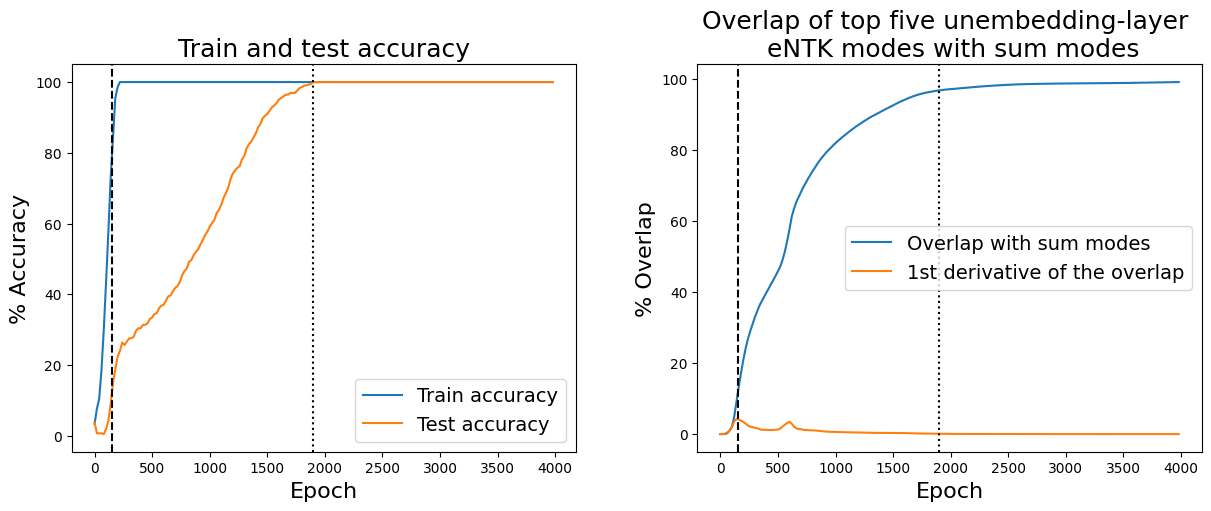

In [45]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    1,2, figsize=(12, 5),
    #sharex='col', sharey='row',
    constrained_layout=True
)

fig.get_layout_engine().set(wspace=0.1)

x_axis = np.arange(start=0, stop=params.epochs, step=params.log_every)

axs[0].plot(x_axis, tr_acc, label="Train accuracy")
axs[0].plot(x_axis, te_acc, label="Test accuracy")
axs[0].axvline(x=150, linestyle="--", color="black")
axs[0].axvline(x=1900, linestyle=":", color="black")
axs[0].set_xlabel("Epoch", fontsize=16)
axs[0].set_ylabel("% Accuracy", fontsize=16)
axs[0].set_title("Train and test accuracy", fontsize=18)
axs[0].legend(fontsize=14)
#axs[0].grid(True, alpha=0.3)
#axs[0].set_tight_layout()


#axs[1].plot(eigvals.detach().cpu().numpy())
#axs[1].set_yscale('log')
#axs[1].set_xlabel("Eigenvalue index", fontsize=16)
#axs[1].set_ylabel("Log(Eigenvalue)", fontsize=16)
#axs[1].set_title("Full eNTK eigenspectrum at convergence", fontsize=18)
#axs[1].legend()


x_axis_2 = np.arange(start=0, stop=params.epochs, step=params.log_every)

axs[1].plot(x_axis_2, o_sums_n, label = "Overlap with sum modes")
#axs[1].plot(x_axis_2, te_acc, label="Test accuracy")
axs[1].plot(x_axis_2, o_1stderiv, label = "1st derivative of the overlap")
#plt.plot(x_axis, o_diffs_n, label = "2nd cliff % overlap with diff modes")
axs[1].legend(fontsize=14)
axs[1].axvline(x=1900, linestyle=":", color="black")
axs[1].axvline(x=150, linestyle="--", color="black")
axs[1].set_title("Overlap of top five unembedding-layer \n eNTK modes with sum modes", fontsize=18)  # eigenvectors 57-112
axs[1].set_xlabel("Epoch", fontsize=16)
axs[1].set_ylabel("% Overlap", fontsize=16)

plt.show()

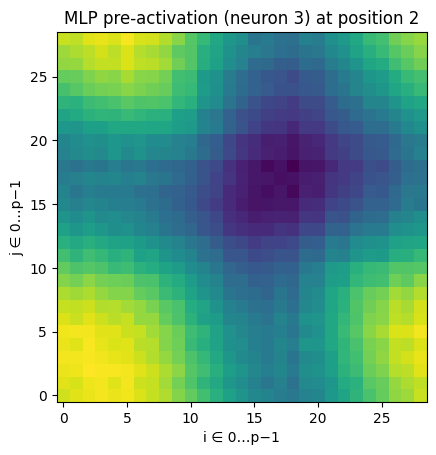

In [30]:
# === Visualize MLP pre-activation for a single neuron over all (i, j) ===
import matplotlib.pyplot as plt

device = next(model.parameters()).device
p = params.p
pos = 2        # which position's MLP pre-activation to visualize (0, 1, or 2)
k = 3         # neuron index in the MLP hidden layer (0 .. d_mlp-1)

# Build the full grid (i, j, <third token = p>) using your data helper
X_dummy, _ = gen_total_data(p)                    # X shape: [p^2, 3] with last token = p
seq = t.tensor(X_dummy, dtype=t.long, device=device)

# Capture the MLP pre-activation: pre = x_after_attn @ W_in
caps = []
def mlp_preact_hook(module, inp, out):
    x_after_attn = inp[0]                   # shape [B, S, d_model]
    pre = x_after_attn @ module.W_in        # shape [B, S, d_mlp]
    caps.append(pre.detach())

h = model.transformer_block.mlp.register_forward_hook(mlp_preact_hook)
with t.no_grad():
    _ = model(seq)                          # forward produces logits at pos=2; hook grabs pre-acts
h.remove()

pre = t.cat(caps, dim=0)                    # [p^2, 3, d_mlp]
img = pre[:, pos, k].reshape(p, p).detach().cpu().numpy()

plt.figure()
plt.imshow(img, origin='lower',
           extent=[-0.5, p-0.5, -0.5, p-0.5], interpolation='none')
plt.gca().set_aspect('equal', 'box')
plt.xlabel('i ∈ 0…p−1'); plt.ylabel('j ∈ 0…p−1')
plt.title(f"MLP pre-activation (neuron {k}) at position {pos}")
plt.show()

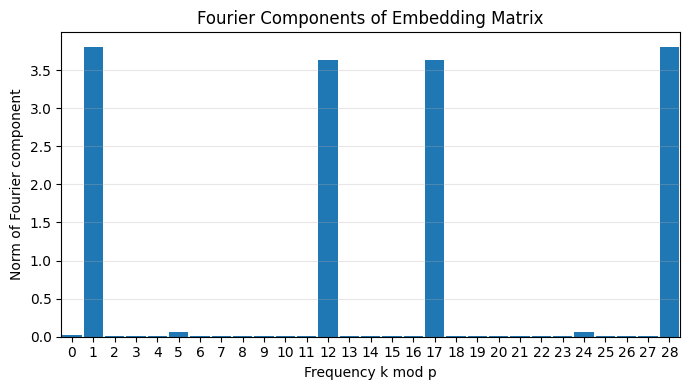

In [31]:
# Check that the embedding matrix localizes to a few Fourier frequencies. (Take Fourier transform along input direction of W_E & compute L^2 norm along the other direction.)

W_E = model.embed.W_E.detach().to("cpu")[:params.p, :]    # shape (p, d_model)
spectrum = t.fft.fft(W_E, dim=0)                          # FT along imput direction. Shape (p, d_model)

l2_norm = (spectrum.abs() ** 2).mean(dim=1).numpy()
freqs = np.arange(params.p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(freqs, l2_norm, width=0.9, align="center")
ax.set_xlabel("Frequency k mod p")
#ax.set_ylabel("L2 norm in d_model direction")
ax.set_ylabel("Norm of Fourier component")
ax.set_title("Fourier Components of Embedding Matrix")
ax.set_xlim(-0.5, len(freqs) - 0.5)

# Keep ticks readable for large p
if len(freqs) <= 40:
    ax.set_xticks(freqs)
else:
    step = max(1, len(freqs)//20)
    ax.set_xticks(np.arange(0, len(freqs), step))

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Reproduce Table 2

In [32]:
entk = empirical_ntk_by_layer_cpu(model.to(device), X.to(device), X.to(device))

In [33]:
print(*entk)

embed.W_E pos_embed.W_pos transformer_block.attn.W_Q transformer_block.attn.W_K transformer_block.attn.W_V transformer_block.attn.W_O transformer_block.mlp.W_in transformer_block.mlp.W_out unembed.W_U


To reproduce Table 2, we manually compute the eNTK eigendirections at each layer. E.g.:


In [34]:
# Replace with name of the appropriate layer.

eigvals, eigvecs = eig_decompose(((entk['unembed.W_U'])[:,:,:30,:30]).mean(dim=(2,3)), topk=40)

In [35]:
c1 = eigvecs[:,0:5].to(device)
Q = c1.cpu().numpy()

In [38]:
s, ov = subspace_overlap(Q, feats, key='sum')
print("singular values:", s, "   overlap:", ov)

singular values: [0.99744649 0.99676291 0.99570177 0.99239122]    overlap: 3.9646981615785917


In [39]:
c1 = eigvecs[:,5:9].to(device)
Q = c1.cpu().numpy()

In [40]:
s, ov = subspace_overlap(Q, feats, key='axis_sum')
print("singular values:", s, "   overlap:", ov)

singular values: [0.99528381 0.99510614 0.99189808 0.9875252 ]    overlap: 3.9398939149816226
